# 🧹 Analysis & Exploration of All Combined Cleaned Comments Dataset

Notebook ini digunakan untuk membaca, menganalisis, dan memeriksa hasil penggabungan (*concat*) 3 file data mentah CSV dan pembersihan (*preprocessing*) teks komentar warganet dari berkas `data/interim/cleaned_comments_all.csv`.

## 1. Import Libraries

In [1]:
from collections import Counter
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options agar teks tidak terpotong
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

plt.style.use('seaborn-v0_8-whitegrid')


## 2. Membaca Data Interim Gabungan (`cleaned_comments_all.csv`)

In [2]:
# Path ke file cleaned CSV gabungan di data/interim/
cleaned_csv_path = Path("../data/interim/cleaned_comments_all.csv")
if not cleaned_csv_path.exists():
    cleaned_csv_path = Path("data/interim/cleaned_comments_all.csv")

print(f"📁 Membaca file gabungan: {cleaned_csv_path.resolve()}")
df = pd.read_csv(cleaned_csv_path, encoding="utf-8-sig")

print(f"✅ Total Komentar Terbersihkan (Unik): {len(df)} baris | Total Kolom: {df.shape[1]}")
df.head()

📁 Membaca file gabungan: E:\Documents\aspect_based_SA_EV\data\interim\cleaned_comments_all.csv
✅ Total Komentar Terbersihkan (Unik): 3016 baris | Total Kolom: 9


,comment_id,video_id,user_id_hash,text_original,like_count,published_at,updated_at,extracted_at,text_cleaned
0,Ugyc2M7NWY_akL6jw7V4AaABAg,G_acqAJrRso,1ffdd7b71d8b758ba2fda70c8489c5f6f1ac50efa1cd48b3043031f7decb71d5,"Gila sih, saya terbiasa beli mobkas, gak pernah sepengen ini beli mobil baru, sangat2222 worth it 🤲🏻🤲🏻🤲🏻🤲🏻",224,2025-11-14T14:55:09Z,2025-11-14T14:55:09Z,2026-09-18T04:38:30.738340+00:00,"gila sih, saya terbiasa beli mobkas, tidak pernah sepengen ini beli mobil baru, sangat22 layak it 🤲🏻🤲🏻🤲🏻🤲🏻"
1,UgwulS5ZnSQo1XgY57h4AaABAg,G_acqAJrRso,fbd5eb834774d29e7c90dd3fbffc19356f237826108373895404730ce479c727,"Harga segitu gacor banget sih! Brio, Agya, HRV auto bye bye 😂😂",70,2025-11-14T14:46:48Z,2026-04-11T11:39:35Z,2026-09-18T04:38:30.738340+00:00,"harga segitu sangat bagus banget sih! brio, agya, hrv auto bye bye 😂😂"
2,UgwTWO6yKN3FXmSVzsN4AaABAg,G_acqAJrRso,ac60c02d0d2d6cc6ba16e903ed3fccb2855d42a75966540879e80b1d91c443c1,"carmudi ini jagatreview nya otomotif, detail bgt👍",62,2025-11-14T15:05:42Z,2025-11-14T15:05:42Z,2026-09-18T04:38:30.738340+00:00,"carmudi ini jagatreview nya otomotif, detail bgt👍"
3,UgzX2HRd5KnvTEoRjX94AaABAg,G_acqAJrRso,67add4b7de128ae7a86f45c35c3bae27aff54efd83ca112cdd5de7fc12f57bd0,"EV paling ganteng di range 200-300 jutaan, menurut keyakinan saya 😆",5,2026-04-11T03:16:54Z,2026-04-11T03:16:54Z,2026-09-18T04:38:30.738340+00:00,"ev paling ganteng di range 200-300 jutaan, menurut keyakinan saya 😆"
4,UgxZ5xKKR_upNBtwW2d4AaABAg,G_acqAJrRso,f8ce334270012b1fc72c0c5552383d782b7339667a7fc31331b14a49f3136dd6,I can tell carmudi put a lot of research and amount of time making this video. Great job being so thorough.,9,2025-11-15T10:18:53Z,2025-11-15T10:18:53Z,2026-09-18T04:38:30.738340+00:00,i can tell carmudi put a lot of research and amount of time making this video. great job being so thorough.


## 3. Komparasi Teks Asli (`text_original`) vs Teks Bersih (`text_cleaned`)

In [3]:
# Menampilkan perbandingan 5 sampel teks asli dan teks setelah pembersihan/normalisasi slang
comparison_df = df[["text_original", "text_cleaned"]].sample(min(5, len(df)), random_state=42)
comparison_df

,text_original,text_cleaned
63,JAECOO SURABAYA...JL. RAYA JEMURSARI 213 ( sebelah toyota auto 2000 ),jaecoo surabaya..jl. raya jemursari 213 ( sebelah toyota auto 200 )
2808,"Mohon info, ex2 kan bawahnya ga ketutup. Itu dampaknya apa ya? Perlu beli penutup kah? Trimakasih","mohon info, ex2 kan bawahnya tidak ketutup. itu dampaknya apa ya? perlu beli penutup kah? trimakasih"
102,tungguh2 aja harga semakin bersaing dan semakin banyak jenis mobil listrik yg akan berdatangan mana yg murah itu yg laku yg mahal akan mati jadi proyek gagal,tungguh2 aja harga semakin bersaing dan semakin banyak jenis mobil listrik yg akan berdatangan mana yg murah itu yg laku yg mahal akan mati jadi proyek gagal
2692,Akhirnya yang ditunggu2 masyarakat Indonesia,akhirnya yang ditunggu2 masyarakat indonesia
416,"Solar panel di kap mesin, dan atap , sspertinya akan mengurangi konsumsi listrik untuk lampu led nya. Lumayan","solar panel di kap mesin, dan atap , sspertinya akan mengurangi konsumsi listrik untuk lampu led nya. lumayan"


## 4. Analisis Statistik Karakter & Kata

In [4]:
# Hitung panjang karakter dan jumlah kata
df["char_count_orig"] = df["text_original"].fillna("").apply(len)
df["char_count_clean"] = df["text_cleaned"].fillna("").apply(len)
df["word_count_clean"] = df["text_cleaned"].fillna("").apply(lambda x: len(x.split()))

# Ringkasan statistik
df[["char_count_orig", "char_count_clean", "word_count_clean"]].describe()

,char_count_orig,char_count_clean,word_count_clean
count,3016.000000,3016.000000,3016.000000
mean,90.020557,90.240716,15.090517
std,139.391096,138.555300,22.458824
min,1.000000,1.000000,1.000000
25%,34.000000,34.000000,6.000000
50%,58.000000,58.000000,10.000000
75%,102.000000,102.000000,17.000000
max,3076.000000,3015.000000,450.000000


### 4.1 Visualisasi Distribusi Panjang Teks

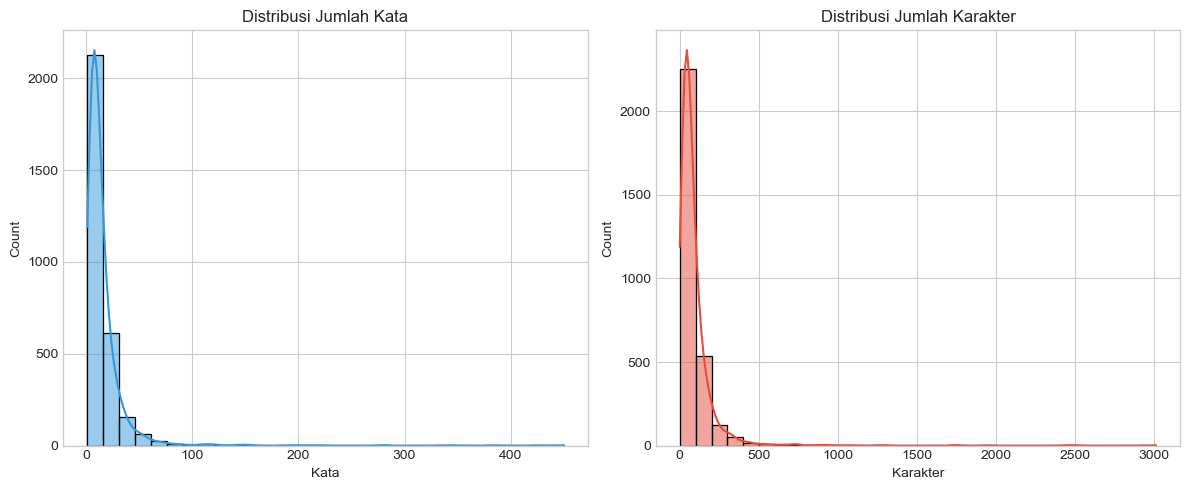

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['word_count_clean'], bins=30, kde=True, color='#3498db', ax=axes[0])
axes[0].set_title('Distribusi Jumlah Kata')
axes[0].set_xlabel('Kata')

sns.histplot(df['char_count_clean'], bins=30, kde=True, color='#e74c3c', ax=axes[1])
axes[1].set_title('Distribusi Jumlah Karakter')
axes[1].set_xlabel('Karakter')

plt.tight_layout()
plt.show()

## 5. Kata yang Paling Sering Muncul (*Top Frequent Words*)

In [6]:
# Filter kata-kata umum (stopwords) agar frekuensi lebih representatif
STOPWORDS = set(['di', 'tidak', 'yg', 'dan', 'ini', 'ada', 'yang', 'nya', 'bisa', 'lebih', 
                 'kalau', 'dari', 'dengan', 'saya', 'tapi', 'untuk', 'sama', 'itu', 'aja', 
                 'juga', 'buat', 'ya', 'kan', 'ke', 'sudah', 'kalo', 'pada', 'atau', 'jadi', 
                 'gak', 'ga', 'akan', 'lagi', 'saja', 'pun'])

all_words = [word for word in " ".join(df["text_cleaned"].dropna()).split() if word not in STOPWORDS]

word_counts = Counter(all_words)
top_20_words = pd.DataFrame(word_counts.most_common(20), columns=["Kata", "Frekuensi"])
top_20_words

,Kata,Frekuensi
0,mobil,724
1,harga,307
2,j5,203
3,beli,200
4,listrik,198
5,atto,193
6,1,189
7,ev,170
8,banget,160
9,udah,159


### 5.1 Visualisasi Top 20 Kata Terbanyak

C:\Users\HP\AppData\Local\Temp\ipykernel_25792\113064357.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_words, x='Frekuensi', y='Kata', palette='viridis')


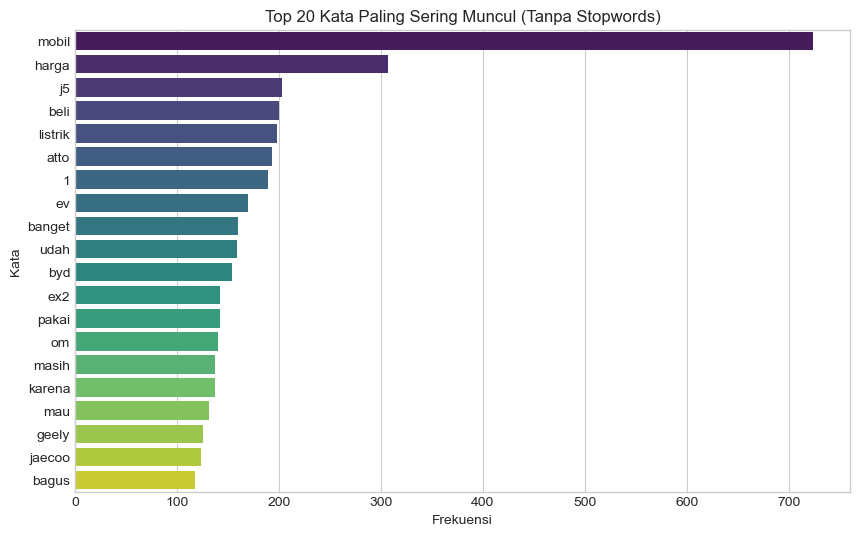

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_20_words, x='Frekuensi', y='Kata', palette='viridis')
plt.title('Top 20 Kata Paling Sering Muncul (Tanpa Stopwords)')
plt.xlabel('Frekuensi')
plt.ylabel('Kata')
plt.show()

## 6. Sampel Komentar Terkait Aspek Utama (EV & SPKLU)

In [8]:
# Filter komentar yang mendiskusikan SPKLU / pengisian daya
spklu_comments = df[df["text_cleaned"].str.contains("stasiun pengisian|spklu|mengisi daya", case=False, na=False)][["text_original", "text_cleaned", "like_count"]]
print(f"🔌 Ditemukan {len(spklu_comments)} komentar membahas Infrastruktur/SPKLU:")
spklu_comments.head(10)

🔌 Ditemukan 26 komentar membahas Infrastruktur/SPKLU:


,text_original,text_cleaned,like_count
84,"Buat dipake krj wort nih, range 400an km bs ngecas seminggu sekali nh dipom bensin😂","buat dipake krj wort nih, range 400an km bs mengisi daya seminggu sekali nh dipom bensin😂",1
489,"Bang kali2 bahas perkembangan spklu dong, pengen tau prkembangan dan mantainnya apakah sudah bagus","bang kali2 bahas perkembangan stasiun pengisian kendaraan listrik umum dong, pengen tau prkembangan dan mantainnya apakah sudah bagus",0
582,"Jaecoo J5. sub merek dari pabrikan china (cherry)\r\n\r\ngila gila, woow keren keren. atto1 sih lewat jauh sama ini maah\r\nmendingan ini kamana2. cuma hrga naik dikits, lega lbh mewah, lebih gedean 😃\r\nSUV yg mahal itu jga bisa kelibas / kelawan sama ini.\r\nsudah masuk duduk di seat driper & duduk di baris 2nya.\r\nPanorimac roofnya, mantap gede bener. sayangnya gk bisa kebuka.\r\nyg bisa kebuka, Polytron G3+, hrga 339jt (tp sewa batery). hmmm naksir salah 1 nya\r\n\r\ntp gw tggu bbrapa thn kedepan. mobil listrik makin murah.\r\npilihan makin banyak, pasti jenisnya bervariasi.\r\nspklu makin banyak, ngecasnya makin cepat (info pabrikan lain dr china)\r\n\r\ntp bgitu popupalsi makin bnyak, infrastruktur bnyak.\r\npajaknya dinaikin ............ hahahahahaha","jaecoo j5. sub merek dari pabrikan china (cherry) gila gila, woow keren keren. atto1 sih lewat jauh sama ini maah mendingan ini kamana2. cuma hrga naik dikits, lega lbh mewah, lebih gedean 😃 suv yg mahal itu jga bisa kelibas / kelawan sama ini. sudah masuk duduk di seat driper & duduk di baris 2nya. panorimac roofnya, bagus gede bener. sayangnya tidak bisa kebuka. yg bisa kebuka, polytron g3+, hrga 339jt (tp sewa batery). hmm naksir salah 1 nya tapi gw tggu bbrapa thn kedepan. mobil listrik makin murah. pilihan makin banyak, pasti jenisnya bervariasi. stasiun pengisian kendaraan listrik umum makin banyak, ngecasnya makin cepat (info pabrikan lain dari china) tapi bgitu popupalsi makin bnyak, infrastruktur bnyak. pajaknya dinaikin .. hahahahahaha",1
1173,"semoga di Kaltim makin banyak SPKLU, biar tenang kalo mau beli mobil listrik.\r\n\r\n\r\nKesel banget LCGC makin mahal, kualitas gak ngikut naik.","semoga di kaltim makin banyak spklu, biar tenang kalo mau beli mobil listrik. kesel banget lcgc makin mahal, kualitas tidak ngikut naik.",12
1615,"Gapunya wall charger ya sama aja, SPKLU belum banyak","gapunya wall charger ya sama aja, stasiun pengisian kendaraan listrik umum belum banyak",0
1920,enak klo bisa ngecas dirumah,enak kalau bisa mengisi daya dirumah,1
1942,"dari info di video, daya tempuh 10 kwh sekitar 100an kilometer.\r\ndengan asumsi efisiensi listrik 75 persen maka dibutuhkan 13,33 kwh untuk ngecas 10 kwh.\r\nterus 1 kwh sekitar Rp. 1.450, maka untuk menempuh 100 kilometer hanya butuh ongkos listrik tidak sampai 20 ribu rupiah 😅\r\n10 kwh dibagi 75 persen = 13,33 kwh\r\n13,33 kwh dikali Rp. 1450/kwh = Rp. 19.333\r\n\r\nedit:\r\nbiaya 1 kwh kategori R2/R3 = Rp. 1.700\r\n13,33 kwh dikali Rp. 1700/kwh = Rp. 22.661\r\nuntuk spklu 1 kwh = Rp.2.500\r\n13,33 kwh dikali Rp. 2.500 = Rp. 33.325\r\ndata ini hanya perhitungan kasar aja dan untuk spklu, efisiensi nya bisa sampai 95 persen, tapi malas ngitung lagi.\r\nkita tunggu saja pengetesan real nya kalo mobil nya udah banyak yg punya 😅","dari info di video, daya tempuh 10 kwh sekitar 100an kilometer. dengan asumsi efisiensi listrik 75 persen maka dibutuhkan 13,33 kwh untuk mengisi daya 10 kwh. terus 1 kwh sekitar rp. 1.450, maka untuk menempuh 100 kilometer hanya butuh ongkos listrik tidak sampai 20 ribu rupiah 😅 10 kwh dibagi 75 persen = 13,33 kwh 13,33 kwh dikali rp. 1450/kwh = rp. 19.33 edit: biaya 1 kwh kategori r2/r3 = rp. 1.700 13,33 kwh dikali rp. 1700/kwh = rp. 22.661 untuk stasiun pengisian kendaraan listrik umum 1 kwh = rp.2.500 13,33 kwh dikali rp. 2.500 = rp. 33.325 data ini hanya perhitungan kasar aja dan untuk spklu, efisiensi nya bisa sampai 95 persen, tapi malas ngitung lagi. kita tunggu saja pengetesan real nya kalo mobil nya udah banyak yg

## 7. Validasi Data Kosong (Empty String & Noise Check)

In [9]:
# Mengecek apakah ada komentar yang menjadi kosong (empty string) setelah text cleaning
df['is_empty'] = df['text_cleaned'].astype(str).str.strip() == ''
empty_rows = df[df['is_empty']]

print(f"⚠️ Terdapat {len(empty_rows)} baris kosong pasca-pembersihan.")
if len(empty_rows) > 0:
    display(empty_rows[['text_original', 'text_cleaned']].head())
    # Jika ada, rekomendasikan hapus di pipeline data extraction selanjutnya


⚠️ Terdapat 0 baris kosong pasca-pembersihan.
